<a href="https://colab.research.google.com/github/Anuoluwapo65/pytorch-jax-implementation/blob/main/self_attention_Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#####standard libraries######
import os
import json
import tqdm
from tqdm.notebook import tqdm
import numpy as np
import math

import time
#### plotting-libraries#####
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set_theme()
sns.reset_orig()

##### torch libraries #######
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
##### torchvision######
import torchvision
from torchvision.datasets import CIFAR100
from torchvision import transforms
###############

In [ ]:
!pip install pytorch_lightning >= 1.4

ERROR: Could not find a version that satisfies the requirement 1.4 (from versions: none)
ERROR: No matching distribution found for 1.4


In [ ]:
 !pip install --quiet pytorch-lightning>=1.4

In [ ]:
import pytorch_lightning as pl

In [ ]:
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

Single -Attention-Mechanism

```
# This is formatted as code
```



In [ ]:
import urllib.request
from urllib.error import HTTPError
data_path = "./_data_path"

checkpoint_path = ".checkpoint_path"
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial6/"

pretrained_filename = ["ReverseTask.ckpt", "SetAnomalyTask.ckpt"]


def configure_seed(seed = 42):
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  pl.seed_everything(seed)


def get_device(device):
  return torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

def pretrained_get_checkpoint_path(
    target_dir = checkpoint_path, file_name = pretrained_filename, source_dir = base_url):
      os.makedirs(target_dir, exist_ok = True)
      for file in file_name:
        file_path = os.path.join(target_dir, file)
        if not os.path.isfile(file_path):
          url = source_dir + file
          print(f" downloading this {url}")
          try:
            urllib.request.urlretrieve(url, file_path)
          except HTTPError as e:
               print("download this model from google link")

pretrained_get_checkpoint_path()

 downloading this https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial6/ReverseTask.ckpt


In [ ]:
def scaled_dot_product(q, k, v, mask = None):
  d_k = q.size()[-1]
  atten_logits = torch.matmul(q, k.transpose(-2, -1))
  atten_logits = atten_logits / math.sqrt(d_k)
  if mask is not None:
    atten_logits = atten_logits.masked_fill(mask == 0, -9e-15)
  attention = F.softmax(atten_logits, dim = -1)
  values = torch.matmul(attention, v)
  return values, attention

In [ ]:
seq_len , d_k = 3, 2

q = torch.randn(seq_len, d_k)
k = torch.randn(seq_len, d_k)
v = torch.randn(seq_len, d_k)

values, attention = scaled_dot_product(q, k, v)

print(q)
print(k)
print(v)
print(values)
print(attention)


tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]])
tensor([[ 2.2082, -0.6380],
        [ 0.4617,  0.2674],
        [ 0.5349,  0.8094]])
tensor([[ 1.1103, -1.6898],
        [-0.9890,  0.9580],
        [ 1.3221,  0.8172]])
tensor([[ 0.5698, -0.1520],
        [ 0.5379, -0.0265],
        [ 0.2246,  0.5556]])
tensor([[0.4028, 0.2886, 0.3086],
        [0.3538, 0.3069, 0.3393],
        [0.1303, 0.4630, 0.4067]])


In [ ]:
def expand_mask(mask):
 assert mask.ndim >= 2, "mask must be at least two dimension pattern"
 if mask.ndim == 3:
  mask = mask.unsqueeze(1)
 while mask.ndim < 4:
   mask = mask.squeeze(0)
 return mask


Multi-Head_attention-Mechanism

In [ ]:
class MultiheadAttentionMechanism(nn.Module):
  def __init__(self, input_dim, embed_dim, num_heads):
    super().__init__()

    if input_dim != embed_dim:
      raise ValueError("input_dim must be equal to embed_dim")

    self.input_dim = input_dim
    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads

    self.qkv_proj = nn.Linear(input_dim, 3*embed_dim)
    self.o_proj = nn.Linear(embed_dim, input_dim)

    self._reset_parameters()

  def _reset_parameters(self):
    nn.init.xavier_uniform_(self.qkv_proj.weight)
    self.qkv_proj.bias.data.fill_(0)
    nn.init.xavier_uniform_(self.o_proj.weight)
    self.o_proj.bias.data.fill_(0)

  def forward(self, x, mask = None, return_attention = False):
    batch_size, seq_len, _ = x.size()

    qkv = self.qkv_proj(x)
    qkv = qkv.reshape(batch_size, seq_len, self.num_heads, 3*self.head_dim)
    qkv = qkv.permute(0,2,1,3)
    q, k, v = qkv.chunk(3, dim = -1)

    values, attention = scaled_dot_product(q, k, v, mask = mask)
    values = values.permute(0,2,1,3)
    values = values.reshape(batch_size, seq_len, self.embed_dim)
    o = self.o_proj(values)

    if return_attention:
      return o, attention
    else:
      return o

In [ ]:
class encoder_block(nn.Module):
  def __init__(self, input_dim, num_heads, dim_feedforward, dropout = 0.0):
    super().__init__()

    self.input_dim = input_dim
    self.dim_feedforward = dim_feedforward
    self.num_heads = num_heads
    # Corrected typo and assigned nn.Dropout correctly
    self.dropout = nn.Dropout(dropout)

    self.self_attn =  MultiheadAttentionMechanism(input_dim, input_dim, num_heads)

    self.input_net = nn.Sequential(
        nn.Linear(input_dim, dim_feedforward),
        nn.Dropout(dropout),
        nn.Linear(dim_feedforward, input_dim)
    )

    self.norm1 = nn.LayerNorm(input_dim)
    self.norm2 = nn.LayerNorm(input_dim)


  def forward(self, x, mask = None):
    attn_out = self.self_attn(x, mask = mask)
    x = x + self.dropout(attn_out) # Use the correct self.dropout instance
    x = self.norm1(x)

    net = self.input_net(x)
    x = x + self.dropout(net) # Use the correct self.dropout instance
    x = self.norm2(x) # Corrected 'out' to 'x'

    return x

In [ ]:
class Transfomer_encoder(nn.Module):
  def  __init__(self, num_layers, **block_args):
    super().__init__()

    self.layers = nn.ModuleList([encoder_block(**block_args) for _ in range(num_layers)])

  def forward(self, x, mask = None):
    for l in self.layers:
      x = l(x, mask = mask)
    return x

  def get_attention(self, x, mask = None):
    attentions = []
    for l in self.layers:
      _, attn_x = l.self_attn(x, mask = mask, return_attention = True)
      attentions.append(attn_x)
      x = l(x, mask = mask) # Corrected: Pass the mask to subsequent encoder blocks
    return attentions

In [ ]:
import torch.nn as nn

class Positional_encoding(nn.Module):
  def __init__(self, d_model, max_len = 5000):
    super().__init__()

    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype =torch.float).unsqueeze(1)
    div_term_exp = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model))

    pe[:, 0::2] = torch.sin(position * div_term_exp)
    pe[:, 1::2] = torch.cos(position * div_term_exp)

    self.register_buffer('pe', pe, persistent = True)

  def forward(self, x):
    x = x + self.pe[:x.size(1), :]
    return x

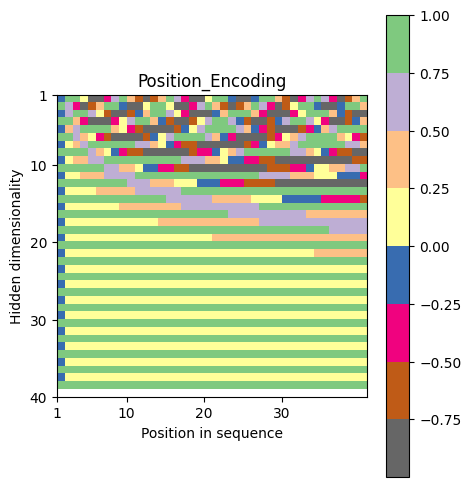

In [ ]:
encod_block = Positional_encoding(d_model = 38, max_len = 40)
pe = encod_block.pe.squeeze().T.cpu().numpy()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(5,6))
pos = ax.imshow(pe, cmap = "Accent_r", extent = (1,pe.shape[1]+1,pe.shape[0]+1,1))
fig.colorbar(pos, ax = ax)
ax.set_title("Position_Encoding")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Hidden dimensionality")
ax.set_xticks([1]+[i*10 for i in range(1,1+pe.shape[0]//10)])
ax.set_yticks([1]+[i*10 for i in range(1,1+pe.shape[1]//10)])
plt.show()


In [ ]:
class Cosinewarmupscheduler(optim.lr_scheduler._LRScheduler):
  def __init__(self,optimizer, warmup, max_iter):
    self.warmup = warmup
    self.max_num_iter = max_iter

    super().__init__(optimizer)

  def get_lr(self):
     lr_factor = self.lr_get_factor(epoch = self.last_epoch)
     return[base_factor * lr_factor for base_factor in self.base_lrs]
  def lr_get_factor(self, epoch):
     lr_factor = 0.5 * (1 + np.cos(np.pi * epoch / self.max_num_iter))
     if epoch <= self.warmup:
      lr_factor *= epoch * 1.0/ self.warmup
     return lr_factor

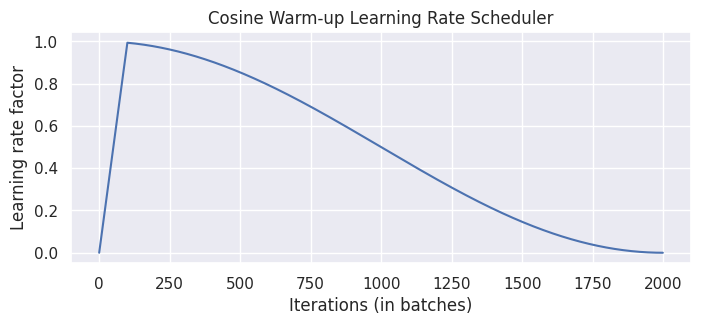

In [ ]:
p = nn.Parameter(torch.empty(4,4))
optimizer = optim.Adam([p], lr=1e-3)
mode = Cosinewarmupscheduler(optimizer=optimizer, warmup=100, max_iter=2000)

### plotting-graph####

epochs = list(range(2000))
sns.set()
plt.figure(figsize=(8,3))
plt.plot(epochs, [mode.lr_get_factor(e) for e in epochs])
plt.ylabel("Learning rate factor")
plt.xlabel("Iterations (in batches)")
plt.title("Cosine Warm-up Learning Rate Scheduler")
plt.show()
sns.reset_orig()

In [ ]:
import pytorch_lightning as pl
import torch.nn as nn

class Transformer_model(pl.LightningModule):
  def __init__(self, input_dim, model_dim, num_classes, num_heads, num_layers, lr, warmup, max_iter, dim_feedforward, dropout = 0.0, input_dropout = 0.0):
    super().__init__()

    self.save_hyperparameters()
    self._create_model()


  def _create_model(self):
    self.input_net = nn.Sequential(
        nn.Dropout(self.hparams.input_dropout),
        nn.Linear(self.hparams.input_dim, self.hparams.model_dim)

    )
    self.pos_encoder = Positional_encoding(d_model = self.hparams.model_dim)

    self.Transformer = Transformer_encoder(num_layers = self.hparams.num_layers,
                                          input_dim = self.hparams.model_dim,
                                          num_heads = self.hparams.num_heads,
                                          dim_feedforward = self.hparams.dim_feedforward,
                                          dropout = self.hparams.dropout)

    self.output_net = nn.Sequential(
        nn.Linear(self.hparams.model_dim, self.hparams.dim_feedforward),
        nn.Dropout(self.hparams.dropout),
        nn.Linear(self.hparams.dim_feedforward, self.hparams.num_classes)
    )


  def forward(self, x, mask = None, add_positional_encoding = True):
    x = self.input_net(x)
    if add_positional_encoding:
      x = self.pos_encoder(x)
      x = self.Transformer(x, mask = mask)
      x = self.output_net(x)
      return x


  @torch.no_grad()
  def get_attention_map(self, x, mask = None, add_positional_encoding = True):
    x = self.input_net(x)
    if add_positional_encoding:
      x = self.pos_encoder(x)
      attentions = self.Transformer.get_attention_map(x, mask = mask)
      return attentions


  def configure_optimizers(self):
    optim = torch.optim.Adam(self.parameters(), lr = self.hparams.lr)
    scheduler = Cosinewarmupscheduler(optim, warmup = self.hparams.warmup, max_iter = self.hparams.max_iter)

    return [optim], [{"lr_scheduler": scheduler, "interval": "step"}]


  def training_step(self, batch, batch_idx):
    raise NotImplementedError

  def validation_step(self, batch, batch_idx):
    raise NotImplementedError


  def test_step(self, batch, batch_idx):
    raise NotImplementedError

In [ ]:
class ReverseDataset(data.Dataset):
  def __init__(self, num_categories, size, seq_len):
    super().__init__()

    self.num_categories = num_categories
    self.size = size
    self.seq_len = seq_len
    self._generate_data()

  def _generate_data(self):
    self.data = torch.randint(self.num_categories, size =(self.size, seq_len))

  def __len__(self):
    return self.size


  def __get__item(self, idx):
    late = self.data[idx]
    labels = torch.flip(late, dim=(0,))
    return late, labels



In [ ]:
from functools import partial

class Reversed_dataset(data.Dataset):
  def __init__(self, num_categories, size, seq_len):
    super().__init__()

    self.num_categories = num_categories
    self.size = size
    self.seq_len = seq_len

    self._categories_()

  def _categories_(self):
    self.data = torch.randint(self.num_categories, size=(self.size, self.seq_len))

  def __len__(self):
    return self.size

  def __getitem__(self, idx):
    x_ind = self.data[idx]
    label = torch.flip(x_ind, dims =(0, ))
    return x_ind,label



mode = partial(Reversed_dataset, 40, 22)
train_loader = data.DataLoader(mode(50000), batch_size = 128, shuffle = True, num_workers = 0, pin_memory_device = "cpu", pin_memory = False)
val_loader = data.DataLoader(mode(25000), batch_size = 128, num_workers = 0,  pin_memory_device = "cpu", shuffle = False, pin_memory = False)
test_loader = data.DataLoader(mode(5000), batch_size = 128, shuffle = False, pin_memory = 0, pin_memory_device = "cpu", num_workers = 0)

In [ ]:
import urllib.request
from urllib.error import HTTPError
data_path = "./data_path"
checkpoint_path = ".checkpoint_path"
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial6/"
pretrained_model =  ["ReverseTask.ckpt", "SetAnomalyTask.ckpt"]

def configure_seed(seed = 42):
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  pl.seed_everything(seed)

def get_device(device):
  return torch.device("cuda:0") if torch.cuda.is_available()else torch.device("cpu")

def pretrained_get_checkpoint_path(target_dir = checkpoint_path, file_name = pretrained_model, source_dir = base_url):
  os.makedirs(target_dir,exist_ok = True)
  for file in file_name:
    file_path = os.path.join(target_dir, file)
    if not os.path.isfile(file_path):
      url = source_dir + file
      print(f" downloading this file_name{url}")
      try:
        urllib.request.urlretrieve(url, file_path)
      except HTTPError as e:
        print("download this file from google drive")

pretrained_get_checkpoint_path()

In [ ]:
def scaled_dot_product(q, k, v, mask = None):
  d_k = q.size()[-1]
  attn_logits = torch.matmul(q, k.transpose(-2, -1))
  attn_logits = attn_logits / math.sqrt(d_k)
  if mask is not None:
    attn_logits = attn_logits.masked_fill(mask == 0, -9e15)
  attention = F.softmax(attn_logits, dim = -1)
  values = torch.matmul(attention, v)
  return values, attention

In [ ]:
d_k, seq_len = 4, 5
q = torch.rand(seq_len, d_k)
k = torch.randn(seq_len, d_k)
v = torch.randn(seq_len, d_k)
values, attention = scaled_dot_product(q, k, v)

print(q)
print(k)
print(v)
print(values)
print(attention)

tensor([[0.1374, 0.9091, 0.4961, 0.5455],
        [0.3253, 0.1630, 0.4995, 0.9351],
        [0.4956, 0.0761, 0.4896, 0.1681],
        [0.0580, 0.5149, 0.8236, 0.9420],
        [0.0990, 0.1618, 0.9504, 0.7500]])
tensor([[ 1.1686, -0.5395,  1.2746,  1.0338],
        [-1.3840,  0.2355,  0.0255,  0.3529],
        [-0.2222,  2.4839,  1.2045, -0.3225],
        [ 0.0090, -0.1051,  0.6264,  0.0056],
        [ 1.2398, -1.5900,  0.3372,  1.3123]])
tensor([[-0.6982,  0.2241, -0.8545,  0.4116],
        [ 0.9514,  0.7814, -1.6779,  1.5184],
        [-1.0558,  0.4347,  0.0661, -0.1865],
        [-0.9275, -0.0804,  2.1284, -1.4451],
        [ 0.3662, -1.4457,  0.5106,  0.2779]])
tensor([[-0.5638,  0.1888, -0.0186,  0.0301],
        [-0.3179, -0.1560, -0.0188,  0.1445],
        [-0.3845, -0.1077,  0.0662,  0.0628],
        [-0.4415,  0.0483, -0.0601,  0.1052],
        [-0.3895, -0.0456, -0.0332,  0.1135]])
tensor([[0.1844, 0.1341, 0.4497, 0.1335, 0.0983],
        [0.3131, 0.1172, 0.1665, 0.1412, 0.262

In [ ]:
def expand_mask(mask):
  assert mask.ndim >= 2, "mask dim must be greater than 2"
  if mask.ndim == 3:
    mask = mask.unsqueeze(1)
  while mask.ndim < 4:
    mask = mask.unsqueeze(0)
  return mask

In [ ]:
class MultiheadattentionMechanism(nn.Module):
  def __init__(self,  input_dim, embedd_dim, numhead_dim):
    super().__init__()

    assert embedd_dim % numhead_dim == 0, "embed_dim must be divisible by num-head"

    self.input_dim = input_dim
    self.embedd_dim = embedd_dim
    self.numhead_dim = numhead_dim
    self.head_dim = embedd_dim // numhead_dim


    self.qkv_proj = nn.Linear(input_dim, 3*embedd_dim)
    self.o_proj = nn.Linear(embedd_dim, input_dim)

    self._reset_parameters()

  def _reset_parameters(self):
    nn.init.xavier_uniform_(self.qkv_proj.weight)
    self.qkv_proj.bias.data.fill_(0)
    nn.init.xavier_uniform_(self.o_proj.weight)
    self.o_proj.bias.data.fill_(0)


  def forward(self, x, mask = None, return_attention = False):
    batch_size, seq_len, _ = x.size()
    qkv = self.qkv_proj(x)

    qkv = qkv.reshape(batch_size, seq_len, self.numhead_dim, 3*self.head_dim)
    qkv = qkv.permute(0, 2, 1, 3)
    q, k, v = qkv.chunk(3, dim = -1)


    values, attention = scaled_dot_product(q, k, v, mask = mask)
    values = values.permute(0, 2, 1, 3)
    values = values.reshape(batch_size, seq_len, self.embedd_dim)
    o = self.o_proj(values)

    if return_attention:
      return o, attention
    else:
        return o

In [ ]:
class Transformer_block(nn.Module):
  def __init__(self, input_dim, num_heads, dim_feedforward, dropout = 0.0):
    super().__init__()

    self.input_dim = input_dim
    self.num_heads = num_heads
    self.dim_feedforward = dim_feedforward
    self.dropout = dropout

    ### attn Mechanism part ######
    self.self_attn = MultiheadattentionMechanism(input_dim, input_dim, num_heads)

    self.linear_net = nn.Sequential(
        nn.Linear(input_dim, dim_feedforward),
        nn.Dropout(dropout),
        nn.ReLU(inplace = True),
        nn.Linear(dim_feedforward, input_dim)
    )

    self.norm1 = nn.LayerNorm(input_dim)
    self.dropout = nn.Dropout(dropout)
    self.norm2 = nn.LayerNorm(input_dim)

  def forward(self, x, mask = None):
    attn_out = self.self_attn(x, mask = mask)
    x = x + self.dropout(attn_out)
    x = self.norm1(x)

    linear_out = self.linear_net(x)
    x = x + self.dropout(linear_out)
    x =  self.norm2(x)

    return x


In [ ]:
class Transformer_encoder(nn.Module):
  def __init__(self, num_layers, **block_args):
    super().__init__()

    self.layers = nn.ModuleList([Transformer_block(**block_args) for _ in range(num_layers)])

  def forward(self, x, mask = None):
    for l in self.layers:
      x = l(x, mask = mask)
    return x

  def get_attention_map(self, x, mask = None):
    attention = []
    for l in self.layers:
      _, attn_x  = l.self_attn(x, mask = mask, return_attention = True)
      attention.append(attn_x)
      x = l(x, mask = mask)
    return attention

In [ ]:
class Positional_encoding(nn.Module):
  def __init__(self, d_model, max_len = 5000):
    super().__init__()

    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len,dtype = torch.float32).unsqueeze(1)
    divterm = torch.exp(torch.arange(0, d_model, 2, dtype = torch.float32) * (-math.log(10000.0)/ d_model))
    pe[:, 0::2] = torch.sin(position * divterm)
    pe[:, 1::2] = torch.cos(position * divterm)

    pe = pe.unsqueeze(0)
    self.register_buffer("pe", pe, persistent = False)
  def forward(self, x, mask = None):
    x = x + self.pe[:, : x.size(1)]
    return x


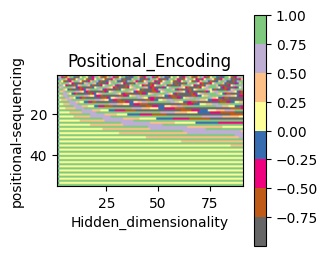

In [ ]:
positional_encoder = Positional_encoding(d_model = 54, max_len = 90)
pe = positional_encoder.pe.squeeze(0).T.cpu().numpy()

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize=(3,3))
pos = plt.imshow(pe, cmap = "Accent_r", extent =(1, pe.shape[1] + 1, pe.shape[0] + 1, 1))
fig.colorbar(pos, ax = axes)
axes.set_title("Positional_Encoding")
axes.set_xlabel("Hidden_dimensionality")
axes.set_ylabel("positional-sequencing")
ax.set_xticks([1]+[i*10 for i in range(1,1+pe.shape[0]//10)])
ax.set_yticks([1]+[i*10 for i in range(1,1+pe.shape[1]//10)])
plt.show()

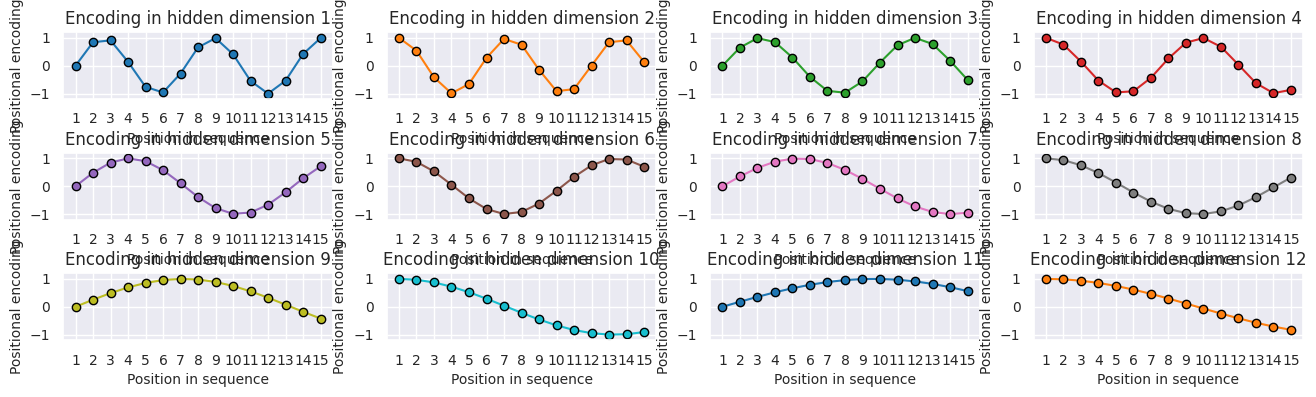

In [ ]:
sns.set_theme()
fig, ax = plt.subplots(nrows = 3, ncols = 4, figsize=(16,4))
ax = [a for a_list in ax for a in a_list]
for i in range(len(ax)):
    ax[i].plot(np.arange(1,16), pe[i,:15], color=f'C{i}', marker="o", markersize=6, markeredgecolor="black")
    ax[i].set_title(f"Encoding in hidden dimension {i+1}")
    ax[i].set_xlabel("Position in sequence", fontsize=10)
    ax[i].set_ylabel("Positional encoding", fontsize=10)
    ax[i].set_xticks(np.arange(1,16))
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].tick_params(axis='both', which='minor', labelsize=8)
    ax[i].set_ylim(-1.2, 1.2)
fig.subplots_adjust(hspace=0.8)
sns.reset_orig()
plt.show()

In [ ]:
class CosineWarmupscheduler(optim.lr_scheduler._LRScheduler):
  def __init__(self, optimizer, warmup, max_iters):
    self.warmup = warmup
    self.max_num_iter = max_iters

    super().__init__(optimizer)

  def get_lr(self):
    lr_factor = self.lr_get_factor(epoch = self.last_epoch)
    return[base_lr * lr_factor for base_lr in self.base_lrs]

  def lr_get_factor(self,epoch):
    lr_factor  = 0.5 * (1+ np.cos(np.pi *epoch / self.max_num_iter))
    if epoch <= self.warmup:
      lr_factor *= epoch * 1.0/self.warmup
    return lr_factor

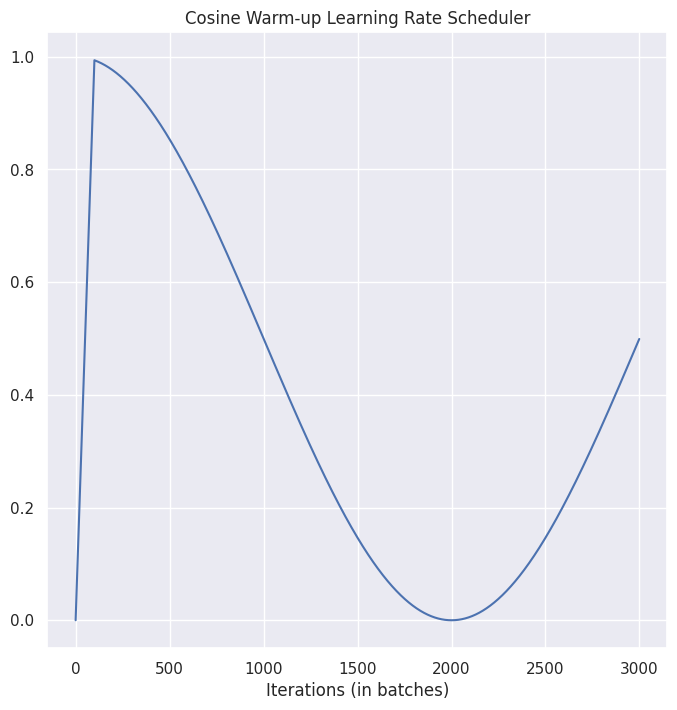

In [ ]:
p = nn.Parameter(torch.empty(4,4))
optimizer = optim.Adam([p], lr = 1e-4)
lr_scheduler = CosineWarmupscheduler(optimizer = optimizer, warmup = 100, max_iters = 2000)

epoch = list(range(3000))
sns.set()
plt.figure(figsize=(8,8))
plt.plot(epoch, [lr_scheduler.lr_get_factor(e) for e in epoch])
plt.xlabel("Iterations (in batches)")
plt.title("Cosine Warm-up Learning Rate Scheduler")
plt.show()
sns.reset_orig()

In [ ]:
class Transformer_model(pl.LightningModule):
  def __init__(self, input_dim, model_dim, num_heads,  num_classes, num_layers, lr, warmup, max_iters,  dropout = 0.0, input_dropout = 0.0):

    super().__init__()
    self.save_hyperparameters() # Save hyperparameters first
    self._create_model() # Then create the model components using hparams

  def _create_model(self):
    self.input_net = nn.Sequential(
      nn.Dropout(self.hparams.input_dropout),
      nn.Linear(self.hparams.input_dim, self.hparams.model_dim)
  )

    self.positional_encoding = Positional_encoding(d_model = self.hparams.model_dim)

    self.transformer = Transformer_encoder(input_dim = self.hparams.model_dim,
                                         dim_feedforward = 2*self.hparams.model_dim,
                                         num_heads = self.hparams.num_heads,
                                         dropout = self.hparams.dropout,
                                         num_layers = self.hparams.num_layers)


    self.output_net = nn.Sequential(
      nn.Linear(self.hparams.model_dim, self.hparams.model_dim),
      nn.LayerNorm(self.hparams.model_dim),
      nn.ReLU(inplace = True),
      nn.Dropout(self.hparams.dropout),
      nn.Linear(self.hparams.model_dim, self.hparams.num_classes)
  )

  def forward(self, x, mask = None, add_positional_encoding = True):
    x = self.input_net(x)
    if add_positional_encoding:
      x = self.positional_encoding(x)
    x = self.transformer(x, mask=mask) # Corrected: self.transformer (lowercase 't')
    x = self.output_net(x)
    return x

  @torch.no_grad()
  def get_attention_maps(self, x, mask=None, add_positional_encoding=True):
        """
        Function for extracting the attention matrices of the whole Transformer for a single batch.
        Input arguments same as the forward pass.
        """
        x = self.input_net(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        attention_maps = self.transformer.get_attention_maps(x, mask=mask)
        return attention_maps



  def configure_optimizers(self):
    optimizer = optim.Adam(self.parameters(), lr = self.hparams.lr)

    lr_scheduler = CosineWarmupscheduler(optimizer,
                                         warmup = self.hparams.warmup,
                                         max_iters = self.hparams.max_iters)
    return [optimizer], [{"scheduler":lr_scheduler, "interval":"step"}]

  def training_step(self, batch, batch_idx):
    raise NotImplementedError

  def validation_step(self, batch, batch_idx):
    raise NotImplementedError

  def test_step(self, batch, batch_idx):
    raise NotImplementedError

In [ ]:
class ReverseDataset(data.Dataset):
  def __init__(self, num_categories, seq_len, size):
    super().__init__()

    self.num_categories = num_categories
    self.seq_len = seq_len
    self.size = size

    self.data = torch.randint(self.num_categories, size = (self.size, self.seq_len))


  def __len__(self):
    return self.size

  def __getitem__(self, idx):
    label_data = self.data[idx]
    labels = torch.flip(label_data, dims = (0,))
    return label_data, labels

In [ ]:
from functools import partial

In [ ]:
dataset = partial(ReverseDataset, 10, 20)
train_loader = data.DataLoader(dataset(50000), batch_size = 256, shuffle = True, drop_last = True, pin_memory = True)
val_loader = data.DataLoader(dataset(1000), batch_size = 256, shuffle = False)
test_loader = data.DataLoader(dataset(500), batch_size = 256, shuffle = False)

In [ ]:
label_data, labels = train_loader.dataset[0]
print("label_data", label_data)
print("labels", labels)

label_data tensor([1, 7, 2, 8, 9, 4, 3, 7, 4, 9, 0, 1, 0, 6, 7, 4, 0, 8, 6, 1])
labels tensor([1, 6, 8, 0, 4, 7, 6, 0, 1, 0, 9, 4, 7, 3, 4, 9, 8, 2, 7, 1])


In [ ]:
class ReversePredictor(Transformer_model):

  def _calculate_loss(self, batch, mode = "train"):
    label_data, labels = batch
    label_data = F.one_hot(label_data, num_classes = self.hparams.num_classes).float()
    preds = self.forward(label_data, add_positional_encoding = True)
    loss = F.cross_entropy(preds.view(-1, preds.size(-1)), labels.view(-1))
    acc = (preds.argmax(dim = -1) == labels).float().mean()

    self.log(f"{mode}_loss", loss)
    self.log(f"{mode}_acc", acc)
    return loss, acc

  def training_step(self, batch, batch_idx):
    loss, _ = self._calculate_loss(batch, mode = "train")

  def validation_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "val")

  def test_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "test")

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint

In [ ]:
def train_reverse(**kwargs):
    # Create a PyTorch Lightning trainer with the generation callback
    root_dir = os.path.join(checkpoint_path, "ReverseTask")
    os.makedirs(root_dir, exist_ok=True)
    trainer = pl.Trainer(default_root_dir=root_dir,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc")],
                         accelerator= "auto",
                         devices=1,
                         max_epochs=100,
                         gradient_clip_val=5)
    trainer.logger._default_hp_metric = None # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(checkpoint_path, "ReverseTask.ckpt")
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        model = ReversePredictor.load_from_checkpoint(pretrained_filename)
    else:
        print("No pretrained model found. Training a new model...")
        model = ReversePredictor(max_iters=trainer.max_epochs*len(train_loader), **kwargs)
        trainer.fit(model, train_loader, val_loader)

    # Test best model on validation and test set
    val_result = trainer.test(model, val_loader, verbose=False)
    test_result = trainer.test(model, test_loader, verbose=False)
    result = {"test_acc": test_result[0]["test_acc"], "val_acc": val_result[0]["test_acc"]}
    return model, result

In [ ]:
reverse_model, reverse_results = train_reverse(input_dim = train_loader.dataset.num_categories,
                                               model_dim = 32, # Increased from 32
                                               num_heads = 1, # Increased from 1
                                               num_classes = train_loader.dataset.num_categories,
                                               num_layers = 1, # Increased from 1
                                               lr = 5e-3,
                                               dropout = 0.0,
                                               warmup = 50,
                                                # Added explicit dim_feedforward
                                               )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Found pretrained model, loading...


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint .checkpoint_path/ReverseTask.ckpt`


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

In [ ]:
import os
# Define the path to the pretrained model checkpoint
pretrained_model_path = os.path.join(".checkpoint_path", "ReverseTask.ckpt")

# Check if the file exists and remove it
if os.path.exists(pretrained_model_path):
    os.remove(pretrained_model_path)
    print(f"Removed existing pretrained model: {pretrained_model_path}")
else:
    print("No pretrained model found to remove.")


Removed existing pretrained model: .checkpoint_path/ReverseTask.ckpt


In [ ]:
print(f"the validation accuracy :{(100.0 * reverse_results["val_acc"]):4.2f}%")
print(f" the test accuracy :{(100.0 * reverse_results["test_acc"]):4.2f}%")

the validation accuracy :10.77%
 the test accuracy :10.91%


In [ ]:
train_data = CIFAR100(root = data_path, train = True, download = True)
img_std = torch.from_numpy(train_data.data).float()/255.0
img_mean = torch.from_numpy(train_data.data).float()/255.0

img_mean = img_mean.permute(0, 3, 1, 2)
img_std = img_std.permute(0,3, 1, 2)

img_mean = img_mean.mean(dim = [0, 2, 3])
img_std = img_std.std(dim = [0, 2, 3])

print(img_mean)
print(img_std)

tensor([0.5071, 0.4866, 0.4409])
tensor([0.2673, 0.2564, 0.2762])


In [ ]:
train_transform = transforms.Compose([transforms.ToTensor(),
                                      transforms.RandomHorizontalFlip(p = 0.5),
                                      transforms.RandomResizedCrop(32, scale = (0.2, 0.8), ratio = (0.2, 0.8)),
                                      transforms.Normalize(img_mean, img_std)])

test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(img_mean, img_std)])

In [ ]:
train_dataset = CIFAR100(root = data_path, train = True, download = True, transform = train_transform)

val_dataset = CIFAR100(root = data_path, download = True, train = True, transform = train_transform)

test_dataset = CIFAR100(root = data_path, download = True, train = False, transform = test_transform)

full_train = int(0.8 * len(train_dataset))
val_train = len(train_dataset) - full_train

train_datasets, _ = torch.utils.data.random_split(train_dataset, [full_train, val_train])
_, val_datasets = torch.utils.data.random_split(val_dataset, [full_train, val_train])


train_loader = data.DataLoader(train_dataset, shuffle = True, batch_size = 256, pin_memory = True, drop_last = True)
val_loader = data.DataLoader(val_dataset, shuffle = False, batch_size = 256)
test_loader = data.DataLoader(test_dataset, batch_size = 256, shuffle = False)

In [ ]:
import os
os.environ["TORCH_HOME"] = checkpoint_path
pretrained_model = torchvision.models.resnet34(weights = "DEFAULT")

pretrained_model.fc = nn.Sequential()
pretrained_model.classifier = nn.Sequential()

devices = get_device(None) # Pass None as a placeholder for the required argument
# The second call 'devices = get_device(devices)' is redundant and removed
pretrained_model = pretrained_model.to(devices)
pretrained_model.eval()
for p in pretrained_model.parameters():
  p.requires_grad = False

In [ ]:
@torch.no_grad()
def extract_features(dataset, save_file):
  if not os.path.isfile(save_file):
    data_loader = data.DataLoader(dataset, batch_size = 256, shuffle = False, drop_last = False,  num_workers = 1)
    extracted_features = []
    for imgs, _ in tqdm(data_loader):
      imgs = imgs.to(devices) # Move images to the same device as the model
      features  = pretrained_model(imgs)
      extracted_features.append(features)
    extracted_features = torch.cat(extracted_features, dim = 0)
    extracted_features = extracted_features.detach().cpu()
    torch.save(extracted_features, save_file)
  else:
    extracted_features = torch.load(save_file)
  return extracted_features
train_file_path = os.path.join(checkpoint_path, "train_set_features.tar")
train_set_feats = extract_features(train_dataset, train_file_path)
test_file_path = os.path.join(checkpoint_path, "test_set_features.tar")
test_feats = extract_features(test_dataset, test_file_path) # Changed checkpoint_path to test_dataset

In [ ]:
@torch.no_grad()
def extract_features(dataset, save_file):
  if not os.path.isfile(save_file):
    data_loader = data.DataLoader(dataset, batch_size = 256, shuffle = False, drop_last = False, num_workers = 2)
    extracted_features = []
    for img, _ in tqdm(data_loader):
      features = pretrained_model(img)
      extracted_features.append(features)
    extracted_features = torch.cat(extracted_features, dim = 0)
    extracted_features = extracted_features.detach().cpu()
    torch.save(extracted_features, save_file)
  else:
    extracted_features = torch.load(save_file)
    return extracted_features

train_feat_file = os.path.join(checkpoint_path, "train_set_features.tar")
train_test_feats = extract_features(train_dataset, train_feat_file)
test_feat_file = os.path.join(checkpoint_path, "test_set_features.tar")
test_set = extract_features(test_dataset, test_feat_file)


In [ ]:
print("Train:", train_test_feats.shape)
print("Test:", test_set.shape)

Train: torch.Size([50000, 512])
Test: torch.Size([10000, 512])


In [ ]:
labels = train_dataset.targets
label = torch.LongTensor(labels)
num_labels = label.max()+1
sorted_indices = torch.argsort(label).reshape(num_labels, -1)

num_val_exmps = sorted_indices.shape[1]//10

val_indices = sorted_indices[:, :num_val_exmps].reshape(-1)
train_indices = sorted_indices[:, num_val_exmps:].reshape(-1)


train_feats, train_labels = train_test_feats[train_indices], label[train_indices]
val_feats, val_labels = train_test_feats[val_indices], label[val_indices]

In [ ]:
class setAnomalyDataset(data.Dataset):
  def __init__(self, img_feats, labels, set_size = 10, train = True):
    super().__init__()

    self.img_feats = img_feats
    self.labels = labels
    self.set_size = set_size
    self.train = train

    self.num_labels = labels.max()+1
    self.sorted_indices = torch.argsort(self.labels).reshape(self.num_labels, -1)
    if not train:
      self .test_sets = self._create_test_set()
  def _create_test_set(self):
    test_sets = []
    num_imgs = self.img_feats.shape[0]
    np.random.seed(42)
    test_sets = [self.sample_img_net(self.labels[idx]) for idx in range(num_imgs)]
    test_sets = torch.stack(test_sets, dim = 0)
    return test_sets


  def sample_img_net(self, anomaly_label):

    set_label = np.random.randint(self.num_labels-1)
    if set_label >= anomaly_label:
            set_label += 1

        # Sample images from the class determined above
    img_indices = np.random.choice(self.sorted_indices[1], size=self.set_size, replace=False)
    img_indices = self.sorted_indices[set_label, img_indices]
    return img_indices
  def __len__(self):
      return self.img_feats.shape[0]

  def __getitem__(self, idx):
    anomaly = self.img_feats[idx]
    if self.train:
      img_indices = self.sample_img_net(self.labels[idx])

    else:
      img_dices = self.test_set[idx]

    img_net = torch.cat([self.img_feats[img_indices], anomaly [None]], dim = 0)
    indices = torch.cat([img_indices, torch.LongTensor([idx])], dim = 0)
    labels = img_net.shape[0]-1

    return img_net, labels, indices



In [ ]:
import torch
import numpy as np
from torch.utils import data

class SetAnomalyDataset(data.Dataset):
    def __init__(self, img_feats, labels, set_size=10, train=True):
        super().__init__()

        self.img_feats = img_feats
        self.labels = labels
        self.set_size = set_size
        self.train = train

        self.num_labels = int(labels.max().item()) + 1

        # ✅ group indices by class properly
        self.label_to_indices = [
            torch.where(labels == i)[0] for i in range(self.num_labels)
        ]

        if not train:
            self.test_sets = self._create_test_set()

    def _create_test_set(self):
        np.random.seed(42)
        test_sets = [
            self.sample_img_set(self.labels[idx]) for idx in range(len(self.labels))
        ]
        return torch.stack(test_sets, dim=0)

    def sample_img_set(self, anomaly_label):
        # sample from OTHER classes (important for anomaly task)
        other_labels = [i for i in range(self.num_labels) if i != anomaly_label]

        chosen_labels = np.random.choice(other_labels, size=self.set_size, replace=True)

        indices = []
        for lbl in chosen_labels:
            idx = np.random.choice(self.label_to_indices[lbl].numpy())
            indices.append(idx)

        return torch.LongTensor(indices)

    def __len__(self):
        return self.img_feats.shape[0]

    def __getitem__(self, idx):
        anomaly = self.img_feats[idx]

        if self.train:
            img_indices = self.sample_img_set(self.labels[idx])
        else:
            img_indices = self.test_sets[idx]

        img_set = torch.cat([self.img_feats[img_indices], anomaly[None]], dim=0)
        indices = torch.cat([img_indices, torch.LongTensor([idx])], dim=0)

        # anomaly is always last
        target = img_set.shape[0] - 1

        return img_set, target, indices

In [ ]:
set_size = 10
test_labels = torch.LongTensor(test_dataset.targets)
train_anomaly_dataset = SetAnomalyDataset(train_feats, train_labels, set_size = set_size)
val_anomaly_dataset = SetAnomalyDataset(val_feats, val_labels, set_size = set_size, train = False)
test_anomaly_dataset = SetAnomalyDataset(test_set, test_labels, set_size = set_size, train= False)

train_anomaly_dataloader = data.DataLoader(train_anomaly_dataset, batch_size = 256, shuffle = True, drop_last = True, num_workers = 2)
val_anomaly_dataloader = data.DataLoader(val_anomaly_dataset, shuffle = False,batch_size = 256, num_workers = 2)
test_anomaly_dataloader = data.DataLoader(test_anomaly_dataset, batch_size = 256, shuffle = False, drop_last = False, num_workers = 2)

In [ ]:
train_anomaly_dataloader = data.DataLoader(train_anomaly_dataset, batch_size = 256, shuffle = True, drop_last = True, num_workers = 2)
val_anomaly_dataloader = data.DataLoader(val_anomaly_dataset, shuffle = False,batch_size = 256, num_workers = 2)
test_anomaly_dataloader = data.DataLoader(test_anomaly_dataset, batch_size = 256, shuffle = False, drop_last = False, num_workers = 2)

In [ ]:
class AnomalyPredictor(Transformer_model):
  def _calculate_loss(self,batch, mode = "train"):
    img_set, anomaly_position, _ = batch # Correct unpacking
    preds = self.forward(img_set, add_positional_encoding=False) # preds is (batch_size, set_size+1, 1)
    preds = preds.squeeze(dim = -1) # preds becomes (batch_size, set_size+1) - these are logits for each position

    loss = F.cross_entropy(preds, anomaly_position) # Corrected target

    # Accuracy calculation also needs to use anomaly_position as the true label
    acc = (preds.argmax(dim = -1) == anomaly_position).float().mean() # Corrected comparison

    self.log(f"{mode}_loss", loss)
    self.log(f"{mode}_acc", acc, on_step = False, on_epoch = True)
    return loss, acc

  def training_step(self, batch, batch_idx):
    loss, _ = self._calculate_loss(batch, mode = "train")

  def validation_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "val")

  def test_step(self, batch, batch_idx):
    _ = self._calculate_loss(batch, mode = "test")

In [ ]:
def train_anomaly(**kwargs):

  root_dir = os.path.join(checkpoint_path, "SetAnomalyTask")
  os.makedirs(root_dir, exist_ok = True)

  trainer = pl.Trainer(default_root_dir = root_dir,
                       max_epochs = 200,
                       devices = 1,
                       accelerator = "auto",
                       callbacks = [ModelCheckpoint(save_weights_only = True, mode = "max", monitor = "val_acc")],
                       gradient_clip_val = 2)
  trainer.logger._log_graph
  trainer.logger._default_hp_metric = None
  pretrained_filename = os.path.join(checkpoint_path, "SetAnomalyTask.ckpt")
  if os.path.isfile(pretrained_filename):
    print("found pretrained_model from filename")
    model = AnomalyPredictor.load_from_checkpoint(pretrained_filename)
  else:
    model = AnomalyPredictor(max_iters = trainer.max_epochs * len(train_anomaly_dataloader), **kwargs)
    trainer.fit(model, train_anomaly_dataloader, val_anomaly_dataloader)
    model = AnomalyPredictor.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)


  trainer_results = trainer.test(model, train_anomaly_dataloader, verbose = False)
  val_results = trainer.test(model, val_anomaly_dataloader, verbose = False)
  test_results = trainer.test(model, test_anomaly_dataloader, verbose=False)
  result = {"test_acc": test_results[0]["test_acc"], "val_acc": val_results[0]["test_acc"], "train_acc": trainer_results[0]["test_acc"]}

  device = get_device(None)
  model = model.to(device)
  return model, result

In [ ]:
anomaly_model, anomaly_result = train_anomaly(input_dim = train_anomaly_dataset.img_feats.shape[-1],
                                              model_dim = 32,
                                              num_classes = 1,
                                              num_layers =4,
                                              dropout = 0.1,
                                              input_dropout = 0.1,
                                              lr = 5e-4,
                                              warmup = 100)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


found pretrained_model from filename


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.0.2 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint .checkpoint_path/SetAnomalyTask.ckpt`
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Output()

Output()

Output()

In [ ]:
print(f"Train accuracy: {(100.0*anomaly_result['train_acc']):4.2f}%")
print(f"Val accuracy:   {(100.0*anomaly_result['val_acc']):4.2f}%")
print(f"Test accuracy:  {(100.0*anomaly_result['test_acc']):4.2f}%")

Train accuracy: 9.37%
Val accuracy:   9.32%
Test accuracy:  9.03%
